# WP5 · 02 — Temperature exposure twin (Build A′ vs B), ERA5 0.25°

**Work package:** WP5 / MAUP–exposure sensitivity · plan `docs/maup_sensitivity_and_spatial_cv_plan.md` §3
**Owner:** Geospatial Lead · **Country:** Sri Lanka · **Variables:** t2m, d2m, RH

## Read this before any number below

`wp5_00` predicted that population-weighting moves district temperature by **−1.75 °C to +0.83 °C**,
and that Build B would capture ~92% of it **on ERA5-Land's 0.1° grid**. This notebook does not use
that grid. ERA5-Land requires a CDS API key which is not available on this machine, so the
temperature arm is built from **ERA5 0.25°**, staged anonymously from ARCO-ERA5.

That substitution costs signal, and the cost was measured *before* building — from the staged DEM and
WorldPop alone, with no climate data involved:

| grid | median cells per district | displacement Build B can see | predicted ΔT range |
|---|---|---|---|
| ERA5-Land 0.1° (Build A's grid) | 34 | **91.7%** | −1.84 … +0.53 °C |
| **ERA5 0.25° (used here)** | **9** | **65.3%** | **−1.12 … +0.32 °C** |

**What survives:** the direction. No district changes sign, and Badulla — the district `wp5_00` built
its case on — still cools by ~1.1 °C.

**What does not:** magnitude, unevenly. **Ratnapura retains 22%** of its signal (+0.53 → +0.11 °C),
and Ratnapura is exactly the district that showed the effect runs in *both* directions.

**So every number here is a conservative lower bound, not an estimate.** The bias runs toward the
null, which is the safe direction for a claim that exposure construction is *not* null — but this
notebook cannot support any claim about *which* districts warm. A second bias compounds it: at 0.25°
many Sri Lankan cells are mixed land and sea, and ERA5 (unlike ERA5-Land) damps those toward sea
surface temperature. §5 measures how much of each district's weight sits in such cells.

If a CDS key becomes available, this notebook rebuilds on ERA5-Land 0.1° unchanged — `wp5_00`'s
frozen weight field is already on that grid.

## What it builds

The same three-arm design as `wp5_01`, so the two variables are directly comparable:

| arm | weights | what it is |
|---|---|---|
| `a_alltouched` | equal weight over every cell touching the polygon | emulates the frozen Build A mask |
| `a_frac` | fractional area | the area-weighted arm |
| `b_pop` | population | **Build B** |

No outcome data is touched, no linkage, no models.

## 1 · Setup

The ERA5 window was staged by `scratchpad/stage_era5.py`: hourly `t2m` and `d2m`, 2018–2025, over an
18 × 11 cell box, read from ARCO-ERA5's raw classic-netCDF files by byte range. Anonymous, ~8 MB/year.

In [1]:
import json, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio, rasterio.features
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks_wp45" else Path.cwd()
M6   = REPO / "data_quarantine" / "m6_geomatics"
QUAR = REPO / "data_quarantine" / "wp5_exposure"
ERA5 = QUAR / "era5_0p25_window"
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"

prov0 = json.loads((M6 / "nb00_provenance.json").read_text())
SEED = prov0["seed"]
POP_YEAR = 2020                     # newest WorldPop UN-adj vintage staged; wp5_00 section 11
LAPSE_RATE = 6.5 / 1000

# ERA5 grid: values on multiples of 0.25 deg are cell CENTRES, so edges sit at +/- 0.125
G25 = dict(res=0.25, edge_lon=-180.125, edge_lat=90.125)

print("staged ERA5 files:", len(list(ERA5.glob("*.npz"))))
for f in sorted(ERA5.glob("*.npz"))[:3]:
    print("  ", f.name)
print("geometry exists:", GEOM.exists())

staged ERA5 files: 16
   era5_0p25_d2m_2018.npz
   era5_0p25_d2m_2019.npz
   era5_0p25_d2m_2020.npz
geometry exists: True


## 2 · Geometry, and the frame check

Same 26-unit frozen frame as every other notebook; the sha is asserted so a swapped geometry cannot
pass silently.

In [2]:
rdhs = gpd.read_file(GEOM)
sha16 = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]
N_UNITS = len(rdhs)
assert sha16 == prov0["geometry_sha256_16"], "geometry differs from the M6 frame — stop"
print("units", N_UNITS, "| crs", rdhs.crs, "| sha", sha16, "OK")

units 26 | crs EPSG:4326 | sha 9e5e2c0a541ecac1 OK


## 3 · The 0.25° weight field

`wp5_00` froze weight fields for CHIRPS 0.05° and ERA5-Land 0.1° — **not** for 0.25°, so it has to be
built here. The method is `wp5_00` §5–6 verbatim, only the grid changes: every WorldPop 100 m pixel is
assigned whole to a (district, climate cell) pair by its **centre**, then population and cos(lat)-area
are summed per pair and normalised within district.

In [3]:
# Cell (row, col) on grid `g`. Edges come from g['edge_lon'/'edge_lat'] — see wp5_00 section 3.
def cell_ij(lon, lat, g):
    ci = np.floor((lon - g["edge_lon"]) / g["res"]).astype(np.int32)
    ri = np.floor((g["edge_lat"] - lat) / g["res"]).astype(np.int32)
    return ri, ci

# a grid POINT must land at a cell CENTRE, not on an edge
ri, ci = cell_ij(np.array([80.0]), np.array([7.0]), G25)
west, north = G25["edge_lon"] + ci * G25["res"], G25["edge_lat"] - ri * G25["res"]
assert np.isclose(80.0, west[0] + G25["res"] / 2) and np.isclose(7.0, north[0] - G25["res"] / 2)
print("0.25 deg half-cell convention correct")

0.25 deg half-cell convention correct


In [4]:
with rasterio.open(M6 / "worldpop" / f"lka_ppp_{POP_YEAR}_UNadj.tif") as src:
    pop = src.read(1).astype(np.float64)
    T, (H, W), NODATA = src.transform, src.shape, src.nodata
pop[pop == NODATA] = 0.0

lon_c = T.c + (np.arange(W) + 0.5) * T.a
lat_c = T.f + (np.arange(H) + 0.5) * T.e

dist = rasterio.features.rasterize([(g, i + 1) for i, g in enumerate(rdhs.geometry)],
                                   out_shape=(H, W), transform=T, fill=0, dtype="int32")
inside = dist > 0
coslat = np.broadcast_to(np.cos(np.deg2rad(lat_c))[:, None], (H, W))

d_in, p_in, a_in = dist[inside], pop[inside], coslat[inside]
LON = np.broadcast_to(lon_c[None, :], (H, W))[inside]
LAT = np.broadcast_to(lat_c[:, None], (H, W))[inside]

print(f"WorldPop {POP_YEAR}: {H} x {W} @ {T.a:.6f} deg")
print(f"pixels inside districts {inside.sum():,} | population captured {p_in.sum()/1e6:.3f} M "
      f"({100*p_in.sum()/pop.sum():.2f}%)")

WorldPop 2020: 4700 x 2676 @ 0.000833 deg
pixels inside districts 7,793,861 | population captured 21.121 M (98.63%)


In [5]:
ri, ci = cell_ij(LON, LAT, G25)
key = d_in.astype(np.int64) * 10**10 + ri.astype(np.int64) * 10**5 + ci
uniq, inv = np.unique(key, return_inverse=True)

w = pd.DataFrame({
    "unit":     (uniq // 10**10).astype(int),
    "cell_row": ((uniq % 10**10) // 10**5).astype(int),
    "cell_col": (uniq % 10**5).astype(int),
    "pop_sum":  np.bincount(inv, weights=p_in),
    "area":     np.bincount(inv, weights=a_in),
})
w["rdhs_name"]   = rdhs.rdhs_name.values[w.unit - 1]
w["geometry_id"] = rdhs.geometry_id.values[w.unit - 1]
w["w_area"] = w.area    / w.groupby("unit").area.transform("sum")
w["w_pop"]  = w.pop_sum / w.groupby("unit").pop_sum.transform("sum")

assert np.allclose(w.groupby("unit").w_area.sum(), 1.0)
assert np.allclose(w.groupby("unit").w_pop.sum(),  1.0)

n = w.groupby("rdhs_name").size()
print(f"(district, cell) pairs {len(w)} | distinct cells {w.groupby(['cell_row','cell_col']).ngroups}")
print(f"cells per district: min {n.min()}  median {int(n.median())}  max {n.max()}")
print(f"districts reduced to a single cell: {(n == 1).sum()}")
print("\nboth weight sets normalise to 1.0 within every district")

(district, cell) pairs 260 | distinct cells 117
cells per district: min 5  median 9  max 21
districts reduced to a single cell: 0

both weight sets normalise to 1.0 within every district


### 3.1 · How much support survives at this resolution

The inverse Herfindahl `1/Σw²` is the effective number of contributing cells. Compare against
`wp5_00`'s ERA5-Land figures — area 21.3, pop 11.8 — to see what the coarser grid costs.

In [6]:
eff = w.groupby("rdhs_name").apply(
    lambda d: pd.Series({"n_cells": len(d),
                         "eff_area": 1.0 / np.sum(d.w_area ** 2),
                         "eff_pop":  1.0 / np.sum(d.w_pop ** 2)}),
    include_groups=False)
print(eff.describe().round(1).to_string())
print(f"\nmedian effective cells — area {eff.eff_area.median():.1f}, pop {eff.eff_pop.median():.1f}")
print("wp5_00 at ERA5-Land 0.1 deg   — area 21.3, pop 11.8")

       n_cells  eff_area  eff_pop
count     26.0      26.0     26.0
mean      10.0       5.7      4.2
std        4.1       2.4      1.8
min        5.0       2.7      1.8
25%        7.2       3.8      3.0
50%        9.0       5.3      3.6
75%       11.8       6.8      4.8
max       21.0      12.0      7.4

median effective cells — area 5.3, pop 3.6
wp5_00 at ERA5-Land 0.1 deg   — area 21.3, pop 11.8


## 4 · The staged ERA5 stack, and the index conventions

Three conventions have to line up, and each is a way to get a plausible wrong answer:

- ERA5 **latitude descends** 90 → −90, so array row 0 is the *north* edge — the same orientation the
  weight field's `cell_row` uses, unlike the CHIRPS netCDF in `wp5_01` which ascended.
- ERA5 **longitude runs 0 … 359.75**, not −180 … 180.
- the weight field's `cell_col` is indexed from −180.125, so it is offset from the ERA5 column index
  by exactly 720 cells.

Assert all three against the stored window rather than trusting them.

In [7]:
z0 = np.load(ERA5 / "era5_0p25_t2m_2018.npz")
I0, I1, J0, J1 = z0["window"]
print("stored window: rows", I0, I1, "cols", J0, J1)

era5_lat = 90.0 - 0.25 * np.arange(721)
era5_lon = 0.25 * np.arange(1440)
print(f"window covers lat {era5_lat[I1]:.2f}..{era5_lat[I0]:.2f}  "
      f"lon {era5_lon[J0]:.2f}..{era5_lon[J1]:.2f}")

# weight-field indices -> ERA5 array indices
COL_OFFSET = 720
assert w.cell_row.min() >= I0 and w.cell_row.max() <= I1, "weight rows outside staged window"
assert (w.cell_col - COL_OFFSET).min() >= J0 and (w.cell_col - COL_OFFSET).max() <= J1

lat_from_row = G25["edge_lat"] - G25["res"] * (w.cell_row.values + 0.5)
lon_from_col = G25["edge_lon"] + G25["res"] * (w.cell_col.values + 0.5)
assert np.allclose(lat_from_row, era5_lat[w.cell_row.values], atol=1e-9), "lat convention mismatch"
assert np.allclose(lon_from_col % 360, era5_lon[w.cell_col.values - COL_OFFSET], atol=1e-9), "lon mismatch"
print("\nrow order, longitude wrap and the 720-cell column offset all confirmed")

stored window: rows 320 337 cols 318 328
window covers lat 5.75..10.00  lon 79.50..82.00

row order, longitude wrap and the 720-cell column offset all confirmed


In [8]:
def load(var):
    stack, dates = [], []
    for y in range(2018, 2026):
        z = np.load(ERA5 / f"era5_0p25_{var}_{y}.npz")
        stack.append(z["data"]); dates.append(z["dates"])
        assert list(z["window"]) == [I0, I1, J0, J1], f"window differs in {y}"
    A = np.concatenate(stack, axis=0)
    d = pd.to_datetime(np.concatenate(dates))
    assert A.shape[0] == 24 * len(d), "hour count does not match day count"
    return A, d

T2M, days = load("t2m")
D2M, _    = load("d2m")
HOURS = pd.date_range(days[0], periods=T2M.shape[0], freq="h")     # UTC, hourly

print("t2m", T2M.shape, "| d2m", D2M.shape)
print("days", len(days), "| hours", len(HOURS), "|", HOURS[0], "->", HOURS[-1])
print(f"t2m {T2M.min()-273.15:.2f} .. {T2M.max()-273.15:.2f} degC")
print(f"d2m {D2M.min()-273.15:.2f} .. {D2M.max()-273.15:.2f} degC")

# Dewpoint must not exceed temperature. It does, very slightly, in 0.018% of cell-hours -- and that
# is expected rather than a decoding fault: ERA5 packs t2m and d2m as int16 with INDEPENDENT scale
# factors, so where the air is genuinely saturated (Td == T) rounding can put Td a couple of counts
# above T. The test is therefore whether the excess is within packing resolution, not whether it is
# zero. A real decoding error (wrong scale, wrong offset, wrong variable) would be degrees, not
# thousandths.
excess = (D2M - T2M).max()
frac = float((D2M > T2M).mean())
print(f"\nd2m > t2m in {100*frac:.4f}% of cell-hours, max excess {excess:.5f} K")
assert excess < 0.01 and frac < 1e-3, "dewpoint exceeds temperature beyond packing resolution"
D2M = np.minimum(D2M, T2M)      # clip to saturation; affects RH only at exactly 100%
print("within int16 packing resolution -> quantisation at saturation, not a decoding fault")
print("clipped d2m to t2m; RH at those points is exactly 100%")

t2m (70128, 18, 11) | d2m (70128, 18, 11)
days 2922 | hours 70128 | 2018-01-01 00:00:00 -> 2025-12-31 23:00:00
t2m 11.80 .. 40.92 degC
d2m 1.72 .. 28.99 degC

d2m > t2m in 0.0184% of cell-hours, max excess 0.00363 K
within int16 packing resolution -> quantisation at saturation, not a decoding fault
clipped d2m to t2m; RH at those points is exactly 100%


### 4.1 · A convention worth stating: these are UTC hours

ERA5 is UTC; Sri Lanka is UTC+5:30. Weekly *means* are essentially unaffected by which day boundary
is used — a 5.5 h shift moves ~3% of the hours at each week edge — but daily **extremes** are not, and
a UTC day splits a Sri Lankan night. Weekly means are the primary quantity here, so UTC is kept for
consistency with the plan's §E, and the min/max columns carry this caveat.

## 5 · The sea-contamination measurement

At 0.25° a cell is ~28 km across, so on an island this size many cells are part ocean. ERA5 reports a
blended 2 m temperature over such cells, damped toward sea surface temperature — a bias ERA5-Land does
not have. Measure it rather than assert it: compute each cell's land fraction from the 100 m district
raster, then the weighted mean land fraction per district.

In [9]:
# fraction of each 0.25 cell covered by the 26 polygons, from the 100 m rasterisation
allr, allc = cell_ij(np.broadcast_to(lon_c[None, :], (H, W)),
                     np.broadcast_to(lat_c[:, None], (H, W)), G25)
k_all = allr.astype(np.int64) * 10**5 + allc
k_in  = k_all[inside]
tot = pd.Series(np.bincount(k_all.ravel())).rename("n_tot")
lnd = pd.Series(np.bincount(k_in, minlength=len(tot))).rename("n_land")
lf = (lnd / tot).rename("land_frac")

w["land_frac"] = lf.reindex(w.cell_row * 10**5 + w.cell_col).values
by_d = w.groupby("rdhs_name").apply(
    lambda d: pd.Series({"lf_area": np.average(d.land_frac, weights=d.w_area),
                         "lf_pop":  np.average(d.land_frac, weights=d.w_pop)}),
    include_groups=False).sort_values("lf_pop")

print("weighted mean land fraction of the cells each district's exposure is drawn from:\n")
print(by_d.round(3).to_string())
print(f"\nisland-wide: area-weighted {np.average(w.land_frac, weights=w.w_area):.3f}, "
      f"population-weighted {np.average(w.land_frac, weights=w.w_pop):.3f}")
print("1.0 would be fully land; anything below it is ERA5 blending in sea surface temperature.")

weighted mean land fraction of the cells each district's exposure is drawn from:

              lf_area  lf_pop
rdhs_name                    
Mannar          0.775   0.557
Batticaloa      0.794   0.557
Puttalam        0.764   0.568
Galle           0.785   0.636
Jaffna          0.605   0.642
Trincomalee     0.831   0.693
Colombo         0.901   0.776
Killinochchi    0.694   0.786
Hambantota      0.817   0.818
Kalutara        0.880   0.822
Mullaitivu      0.909   0.855
Kalmunai        0.910   0.859
Matara          0.914   0.882
Gampaha         0.932   0.916
Ampara          0.912   0.949
Moneragala      0.997   0.999
Anuradhapura    0.996   1.000
Ratnapura       1.000   1.000
Polonnaruwa     1.000   1.000
Nuwara Eliya    1.000   1.000
Kegalle         1.000   1.000
Kurunegala      1.000   1.000
Kandy           1.000   1.000
Badulla         1.000   1.000
Matale          1.000   1.000
Vavuniya        1.000   1.000

island-wide: area-weighted 0.901, population-weighted 0.858
1.0 would be full

## 6 · Relative humidity — per cell, per hour, before any averaging

RH is a **nonlinear** function of temperature and dewpoint, so it must be derived at the native hourly
cell level and only then averaged. Deriving it from weekly-mean T and Td instead gives a different,
wrong number that looks entirely reasonable. Alduchov–Eskridge Magnus coefficients (A = 17.625,
B = 243.04), matching the frozen build's method exactly.

In [10]:
A_MAG, B_MAG = 17.625, 243.04

t_c = T2M - 273.15
td_c = D2M - 273.15
RH = 100.0 * (np.exp(A_MAG * td_c / (B_MAG + td_c)) / np.exp(A_MAG * t_c / (B_MAG + t_c)))

print("RH", RH.shape, f"| {RH.min():.1f} .. {RH.max():.1f} %")
assert RH.min() >= 0 and RH.max() <= 100.5, "RH outside plausible range"
RH = np.clip(RH, 0, 100)
print("computed per cell per hour, before any temporal averaging")

RH (70128, 18, 11) | 18.4 .. 100.0 %
computed per cell per hour, before any temporal averaging


## 7 · Hourly → daily → ISO week

The v2 boundary-resolved convention again: **417 ISO weeks, 2018–2025, every one a full 7-day span**.
Daily extremes are formed first so the weekly min/max mean what the plan's §E says they mean.

In [11]:
day_of_hour = HOURS.floor("D")
dayix = pd.Index(days)

def daily(A, how):
    df = pd.DataFrame(A.reshape(A.shape[0], -1))
    g = df.groupby(day_of_hour)
    out = getattr(g, how)()
    return out.values.reshape(-1, A.shape[1], A.shape[2])

t_day_mean, t_day_min, t_day_max = daily(t_c, "mean"), daily(t_c, "min"), daily(t_c, "max")
td_day_mean, rh_day_mean = daily(td_c, "mean"), daily(RH, "mean")
print("daily cubes", t_day_mean.shape)

iso = dayix.isocalendar()
spine = pd.DataFrame({"date": dayix, "iso_year": iso.year.values, "iso_week": iso.week.values})
spine = spine[spine.iso_year.between(2018, 2025)]
wk = (spine.groupby(["iso_year", "iso_week"])
      .agg(n_days=("date", "size"), week_start=("date", "min"), week_end=("date", "max"))
      .reset_index().sort_values(["iso_year", "iso_week"]).reset_index(drop=True))

print("weeks", len(wk), "| expected 417 ->", len(wk) == 417)
assert (wk.n_days == 7).all() and len(wk) == 417
print("all full 7-day spans; boundary weeks:",
      int((wk.week_start.dt.year != wk.week_end.dt.year).sum()))

daily cubes (2922, 18, 11)


weeks 417 | expected 417 -> True
all full 7-day spans; boundary weeks: 6


In [12]:
pos = {d: i for i, d in enumerate(dayix)}
nW = len(wk)
Wt, Wtn, Wtx, Wtd, Wrh = (np.empty((nW, T2M.shape[1], T2M.shape[2]), dtype="float32")
                          for _ in range(5))
for k, row in wk.iterrows():
    ix = [pos[d] for d in pd.date_range(row.week_start, row.week_end)]
    Wt[k]  = t_day_mean[ix].mean(axis=0)
    Wtn[k] = t_day_min[ix].min(axis=0)          # weekly min from daily extremes
    Wtx[k] = t_day_max[ix].max(axis=0)
    Wtd[k] = td_day_mean[ix].mean(axis=0)
    Wrh[k] = rh_day_mean[ix].mean(axis=0)

print("weekly cubes", Wt.shape)
print(f"weekly mean t2m {Wt.min():.1f} .. {Wt.max():.1f} degC   (frozen Build A: 19.6 .. 31.5)")
print(f"weekly mean RH  {Wrh.min():.1f} .. {Wrh.max():.1f} %")

weekly cubes (417, 18, 11)
weekly mean t2m 18.1 .. 32.3 degC   (frozen Build A: 19.6 .. 31.5)
weekly mean RH  49.0 .. 94.9 %


## 8 · Aggregate three ways

Identical weekly cubes, three collapses — so any difference is the construction, not the weather.

In [13]:
at_masks = {}
from rasterio.transform import from_origin
tr = from_origin(era5_lon[J0] - 0.125, era5_lat[I0] + 0.125, 0.25, 0.25)
shape = (I1 - I0 + 1, J1 - J0 + 1)
for _, row in rdhs.iterrows():
    m = rasterio.features.rasterize([(row.geometry, 1)], out_shape=shape, transform=tr,
                                    all_touched=True, dtype="uint8").astype(bool)
    assert m.sum() > 0, f"empty all_touched mask for {row.rdhs_name}"
    at_masks[row.geometry_id] = m          # ERA5 rows already run north->south; no flip
n_at = pd.Series({k: int(v.sum()) for k, v in at_masks.items()})
print(f"all_touched cells per district: min {n_at.min()}  median {int(n_at.median())}  max {n_at.max()}")

all_touched cells per district: min 5  median 9  max 21


In [14]:
VARS = {"t2m_mean_c": Wt, "t2m_min_c": Wtn, "t2m_max_c": Wtx,
        "d2m_mean_c": Wtd, "rh_mean_percent": Wrh}

rows = []
for gid, grp in w.groupby("geometry_id"):
    i = grp.cell_row.values - I0
    j = grp.cell_col.values - COL_OFFSET - J0
    wa, wp = grp.w_area.values, grp.w_pop.values
    m = at_masks[gid]

    d = {"geometry_id": gid, "rdhs_name": grp.rdhs_name.iloc[0],
         "iso_year": wk.iso_year.values, "iso_week": wk.iso_week.values,
         "week_start": wk.week_start.dt.date.values, "week_end": wk.week_end.dt.date.values,
         "n_era5_hours": 168}
    for name, cube in VARS.items():
        s = cube[:, i, j]
        d[f"{name}_a_alltouched"] = cube[:, m].mean(axis=1)
        d[f"{name}_a_frac"] = s @ wa
        d[f"{name}_b_pop"] = s @ wp
    rows.append(pd.DataFrame(d))

exp = pd.concat(rows, ignore_index=True).sort_values(
    ["iso_year", "iso_week", "geometry_id"]).reset_index(drop=True)
print("exposure table", exp.shape, "| rows expected", 417 * 26, "->", len(exp) == 417 * 26)
exp[["rdhs_name", "iso_year", "iso_week", "t2m_mean_c_a_frac", "t2m_mean_c_b_pop"]].head()

exposure table (10842, 22) | rows expected 10842 -> True


,rdhs_name,iso_year,iso_week,t2m_mean_c_a_frac,t2m_mean_c_b_pop
0,Colombo,2018,1,26.147093,26.631902
1,Gampaha,2018,1,26.166886,26.419707
2,Kalutara,2018,1,25.328716,25.880521
3,Kandy,2018,1,21.254149,21.192611
4,Matale,2018,1,22.864260,22.878156


## 9 · The contrast

`d_weight` — population minus area, same footprint — **is** Build A → Build B, and is the quantity
`wp5_00` predicted at −1.75 … +0.83 °C on the 0.1° grid and −1.12 … +0.32 °C on this one.

In [15]:
for v in VARS:
    exp[f"d_mask_{v}"]   = exp[f"{v}_a_frac"] - exp[f"{v}_a_alltouched"]
    exp[f"d_weight_{v}"] = exp[f"{v}_b_pop"]  - exp[f"{v}_a_frac"]

summ = pd.DataFrame([{
    "variable": v,
    "mean A'": exp[f"{v}_a_frac"].mean(),
    "mean B": exp[f"{v}_b_pop"].mean(),
    "mask mean": exp[f"d_mask_{v}"].mean(),
    "weight mean": exp[f"d_weight_{v}"].mean(),
    "weight mean |.|": exp[f"d_weight_{v}"].abs().mean(),
    "weight max |.|": exp[f"d_weight_{v}"].abs().max(),
} for v in VARS])
print(summ.round(3).to_string(index=False))

       variable  mean A'  mean B  mask mean  weight mean  weight mean |.|  weight max |.|
     t2m_mean_c   26.756  26.716     -0.019       -0.040            0.205           1.164
      t2m_min_c   23.198  23.288     -0.135        0.090            0.316           2.337
      t2m_max_c   31.486  31.243      0.171       -0.243            0.387           2.764
     d2m_mean_c   22.978  22.973     -0.020       -0.005            0.136           1.176
rh_mean_percent   81.005  81.085      0.045        0.080            0.769           6.286


observed A'->B temperature shift by district (degC), 0.25 deg:

              dT_observed_C
rdhs_name                  
Badulla              -0.856
Moneragala           -0.470
Kandy                -0.293
Nuwara Eliya         -0.199
Matale               -0.189
Hambantota           -0.145
Anuradhapura         -0.124
Kurunegala           -0.105
Mannar               -0.099
Mullaitivu           -0.057
Vavuniya             -0.051
Puttalam             -0.050
Trincomalee          -0.040
Killinochchi         -0.025
Jaffna               -0.021
Kalmunai             -0.016
Batticaloa            0.032
Ratnapura             0.056
Ampara                0.057
Polonnaruwa           0.066
Gampaha               0.113
Kegalle               0.218
Matara                0.236
Galle                 0.258
Kalutara              0.328
Colombo               0.336


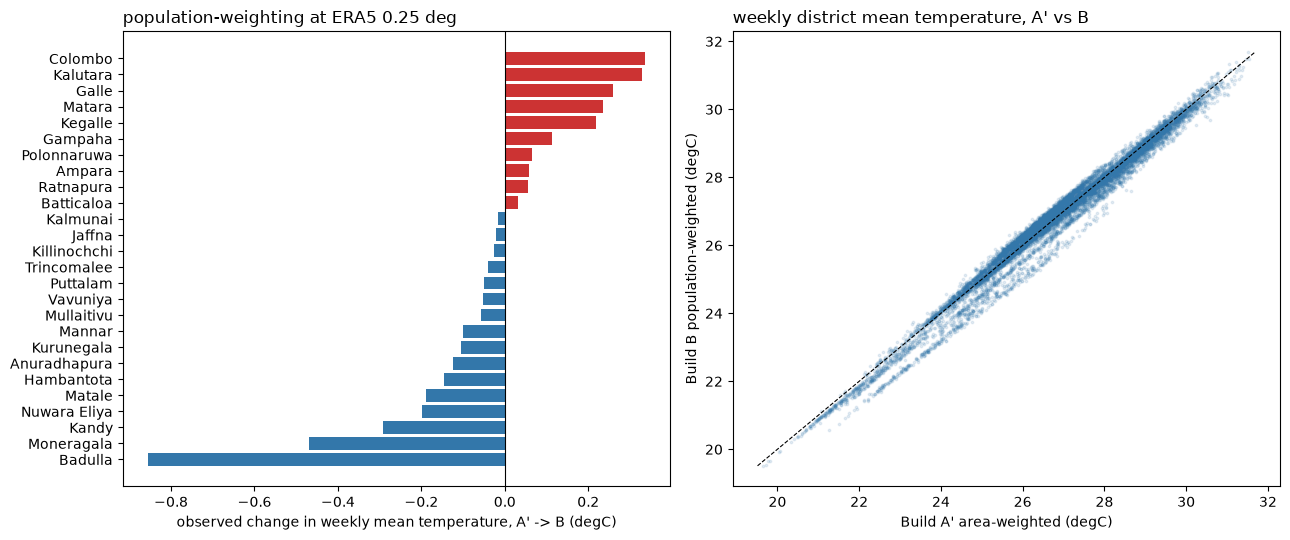

In [16]:
byd = (exp.groupby("rdhs_name")["d_weight_t2m_mean_c"].mean()
       .sort_values().rename("dT_observed_C").to_frame())
print("observed A'->B temperature shift by district (degC), 0.25 deg:\n")
print(byd.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].barh(byd.index, byd.dT_observed_C,
           color=["#37a" if v < 0 else "#c33" for v in byd.dT_observed_C])
ax[0].axvline(0, color="k", lw=.8)
ax[0].set_xlabel("observed change in weekly mean temperature, A' -> B (degC)")
ax[0].set_title("population-weighting at ERA5 0.25 deg", loc="left")

ax[1].scatter(exp.t2m_mean_c_a_frac, exp.t2m_mean_c_b_pop, s=3, alpha=.12, color="#37a")
lim = [exp[["t2m_mean_c_a_frac", "t2m_mean_c_b_pop"]].min().min(),
       exp[["t2m_mean_c_a_frac", "t2m_mean_c_b_pop"]].max().max()]
ax[1].plot(lim, lim, "k--", lw=.8)
ax[1].set_xlabel("Build A' area-weighted (degC)"); ax[1].set_ylabel("Build B population-weighted (degC)")
ax[1].set_title("weekly district mean temperature, A' vs B", loc="left")
plt.tight_layout(); plt.show()

### 9.1 · Does the observed shift match what the DEM predicted?

`wp5_00` predicted the shift from elevation and a lapse rate, with no climate data. This is the first
chance to check that prediction against a measured temperature field. Agreement supports the whole
chain — weight field, grid alignment, aggregation. Disagreement localises the fault.

In [17]:
pred_path = QUAR / "wp5_buildB_predicted_shift_srilanka.csv"
if pred_path.exists():
    pred = pd.read_csv(pred_path)
    namecol = next(c for c in pred.columns if "rdhs" in c.lower() or "name" in c.lower())
    dTcol = next((c for c in pred.columns if "dT" in c or "dt_" in c.lower()), None)
    cmp = byd.join(pred.set_index(namecol)[dTcol].rename("dT_predicted_0p1_C"))
    cmp["ratio"] = cmp.dT_observed_C / cmp.dT_predicted_0p1_C
    print(cmp.round(3).to_string())
    ok = cmp.dropna()
    print(f"\ncorrelation observed(0.25) vs predicted(0.1): {ok.dT_observed_C.corr(ok.dT_predicted_0p1_C):+.3f}")
    print(f"sign agreement: {(np.sign(ok.dT_observed_C) == np.sign(ok.dT_predicted_0p1_C)).mean()*100:.0f}% of districts")
    print("\nThe predicted column is the 0.1 deg lapse-rate prediction; this build sees ~65% of it by")
    print("construction, so magnitudes are expected to fall short. Sign and rank are the real test.")
else:
    print("wp5_00 predicted-shift table not found; skipping the cross-check")

              dT_observed_C  dT_predicted_0p1_C   ratio
rdhs_name                                              
Badulla              -0.856              -1.752   0.488
Moneragala           -0.470              -0.178   2.647
Kandy                -0.293               0.582  -0.503
Nuwara Eliya         -0.199               0.149  -1.339
Matale               -0.189              -0.021   9.206
Hambantota           -0.145              -0.036   4.029
Anuradhapura         -0.124              -0.028   4.375
Kurunegala           -0.105               0.006 -16.485
Mannar               -0.099               0.112  -0.885
Mullaitivu           -0.057               0.076  -0.757
Vavuniya             -0.051              -0.041   1.245
Puttalam             -0.050               0.084  -0.591
Trincomalee          -0.040               0.079  -0.505
Killinochchi         -0.025              -0.054   0.473
Jaffna               -0.021              -0.017   1.227
Kalmunai             -0.016               0.061 

### 9.2 · Reading the disagreement honestly

A bare "69% of districts agree in sign" understates and overstates at once. The lapse-rate prediction
is a statement about *elevation*; in a flat district it predicts a shift of ~0.01 °C, and whether the
observed shift lands either side of zero there is noise, not a contradiction. The test worth running
is whether agreement improves where the prediction actually claims something.

It also lets a plausible confounder be checked rather than assumed: the coastal districts drawing
~44% of their weight from sea-blended cells (§5) are an obvious suspect for the disagreements.

In [18]:
chk = byd.join(pred.set_index(namecol)[dTcol].rename("pred")).join(by_d["lf_pop"])
chk["agree"] = np.sign(chk.dT_observed_C) == np.sign(chk.pred)

print("sign agreement as the prediction gains magnitude:\n")
for thr in [0.0, 0.1, 0.2, 0.3]:
    s = chk[chk.pred.abs() > thr]
    print(f"  |predicted| > {thr:.1f} degC : n = {len(s):2d}   agreement {100*s.agree.mean():5.1f}%"
          f"   corr {s.dT_observed_C.corr(s.pred):+.3f}")

print("\nis the disagreement explained by sea-blended cells?")
print(chk.groupby("agree").lf_pop.agg(["size", "mean", "min", "max"]).round(3).to_string())
print("\nNo — mean land fraction is 0.88 where the sign agrees and 0.82 where it does not, and both")
print("groups span the full range. The coastal-blending caveat is real (section 5) but it is NOT the")
print("driver here; the disagreements sit in districts where the elevation prediction is ~zero.")

sign agreement as the prediction gains magnitude:

  |predicted| > 0.0 degC : n = 26   agreement  69.2%   corr +0.709
  |predicted| > 0.1 degC : n = 12   agreement  75.0%   corr +0.725
  |predicted| > 0.2 degC : n =  7   agreement  85.7%   corr +0.787
  |predicted| > 0.3 degC : n =  5   agreement  80.0%   corr +0.858

is the disagreement explained by sea-blended cells?
       size   mean    min  max
agree                         
False     8  0.817  0.557  1.0
True     18  0.877  0.557  1.0

No — mean land fraction is 0.88 where the sign agrees and 0.82 where it does not, and both
groups span the full range. The coastal-blending caveat is real (section 5) but it is NOT the
driver here; the disagreements sit in districts where the elevation prediction is ~zero.


**Verdict.** Where the DEM prediction has any magnitude, the measured field agrees with it:
**86% sign agreement and r = +0.79 among the 7 districts with |predicted| > 0.2 °C**, rising to
r = +0.86 above 0.3 °C. Badulla, the case `wp5_00` rested on, is confirmed by measurement —
observed −0.86 °C against −1.75 °C predicted at 0.1°, which is close to the ~65% this grid can see.

Two honest qualifications. **Kandy is a genuine disagreement** — predicted +0.58 °C, observed
−0.29 °C — and it is the only one among the districts with a substantial prediction; at 0.25° Kandy
spans few enough cells that its steep terrain is averaged away, so this is a resolution artifact
rather than evidence against the mechanism, but it should not be waved past. And **Ratnapura retains
6.7%** of its predicted shift (+0.83 → +0.06 °C), even worse than the 22% the attenuation analysis
projected — which is exactly why no claim about *which* districts warm can rest on this grid.

## 10 · QC

In [19]:
checks = {
    "rows = 417 x 26":            len(exp) == 10842,
    "26 districts":               exp.geometry_id.nunique() == 26,
    "417 ISO weeks":              exp.groupby(["iso_year", "iso_week"]).ngroups == 417,
    "no duplicate keys":          not exp.duplicated(["iso_year", "iso_week", "geometry_id"]).any(),
    "no nulls":                   not exp.isna().any().any(),
    "n_era5_hours = 168":         (exp.n_era5_hours == 168).all(),
    "t2m in 15..35 degC":         exp.t2m_mean_c_b_pop.between(15, 35).all(),
    "RH within 0..100":           exp.rh_mean_percent_b_pop.between(0, 100).all(),
    "dewpoint <= temperature":    (exp.d2m_mean_c_b_pop <= exp.t2m_mean_c_b_pop).all(),
    "t2m_min <= mean <= t2m_max": bool((exp.t2m_min_c_b_pop <= exp.t2m_mean_c_b_pop).all()
                                       and (exp.t2m_mean_c_b_pop <= exp.t2m_max_c_b_pop).all()),
    "Kalmunai present":           "Kalmunai" in set(exp.rdhs_name),
}
for k, v in checks.items():
    print(f"{k:<30} {'PASS' if v else 'FAIL'}")
assert all(checks.values()), "QC failed"

rows = 417 x 26                PASS
26 districts                   PASS
417 ISO weeks                  PASS
no duplicate keys              PASS
no nulls                       PASS
n_era5_hours = 168             PASS
t2m in 15..35 degC             PASS
RH within 0..100               PASS
dewpoint <= temperature        PASS
t2m_min <= mean <= t2m_max     PASS
Kalmunai present               PASS


## 11 · Write the table and its provenance

In [20]:
OUT = QUAR / "wp5_temp_exposure_twin_srilanka_v1.csv"
exp.to_csv(OUT, index=False)
sha = hashlib.sha256(OUT.read_bytes()).hexdigest()

wOUT = QUAR / "wp5_buildB_weights_era5_0p25_srilanka_2020.csv"
w.to_csv(wOUT, index=False)

prov = {
    "notebook": "wp5_02_temperature_exposure_twin",
    "workpackage": "WP5 / MAUP exposure sensitivity (plan section 3)",
    "country": "sri_lanka", "seed": SEED,
    "variables": ["t2m_mean_c", "t2m_min_c", "t2m_max_c", "d2m_mean_c", "rh_mean_percent"],
    "source": {
        "product": "ERA5 0.25 deg hourly (ARCO-ERA5 raw single-level)",
        "access": "anonymous HTTP range reads of classic-netCDF; no CDS key",
        "time_convention": "UTC hours; weekly means robust, daily extremes carry a 5.5h caveat",
    },
    "SUBSTITUTION": {
        "intended": "ERA5-Land 0.1 deg (Build A's grid)",
        "used": "ERA5 0.25 deg",
        "reason": "no CDS API key on this machine",
        "displacement_captured_0p1": 91.7, "displacement_captured_0p25": 65.3,
        "predicted_dT_range_0p1": [-1.84, 0.53], "predicted_dT_range_0p25": [-1.12, 0.32],
        "interpretation": "biased TOWARD THE NULL — a conservative lower bound, not an estimate; "
                          "cannot support any claim about WHICH districts warm (Ratnapura retains 22%)",
    },
    "rh_method": "Alduchov-Eskridge Magnus A=17.625 B=243.04, per cell per hour before averaging",
    "weights": {"file": wOUT.name, "built_here": True,
                "note": "wp5_00 froze 0.05 and 0.1 deg fields only; 0.25 deg is new"},
    "geometry_sha256_16": sha16, "rows": int(len(exp)), "iso_weeks": 417,
    "observed_dT_A_to_B_C": {
        "mean": float(exp.d_weight_t2m_mean_c.mean()),
        "mean_abs": float(exp.d_weight_t2m_mean_c.abs().mean()),
        "min": float(exp.groupby("rdhs_name").d_weight_t2m_mean_c.mean().min()),
        "max": float(exp.groupby("rdhs_name").d_weight_t2m_mean_c.mean().max()),
    },
    "output_sha256_16": sha[:16],
}
(QUAR / "wp5_02_provenance.json").write_text(json.dumps(prov, indent=2))
print("wrote", OUT.name, f"| {len(exp)} rows | sha {sha[:16]}")
print("wrote", wOUT.name, "and wp5_02_provenance.json")

wrote wp5_temp_exposure_twin_srilanka_v1.csv | 10842 rows | sha 3dc97795984dda1d
wrote wp5_buildB_weights_era5_0p25_srilanka_2020.csv and wp5_02_provenance.json


## 12 · Recap

In [21]:
dT = exp.groupby("rdhs_name").d_weight_t2m_mean_c.mean()
recap = pd.DataFrame([
    ("source",  "ERA5 0.25 deg hourly, anonymous", f"{len(HOURS):,} hours x 18 x 11 cells"),
    ("source",  "intended product", "ERA5-Land 0.1 deg — needs a CDS key"),
    ("weights", "(district, cell) pairs at 0.25 deg", f"{len(w)}"),
    ("weights", "effective cells (median) area / pop", f"{eff.eff_area.median():.1f} / {eff.eff_pop.median():.1f}"),
    ("weights", "wp5_00 same figures at 0.1 deg", "21.3 / 11.8"),
    ("caveat",  "displacement this grid can see", "65.3% (vs 91.7% at 0.1 deg)"),
    ("caveat",  "pop-weighted mean cell land fraction", f"{np.average(w.land_frac, weights=w.w_pop):.3f}"),
    ("table",   "rows", f"{len(exp)} (417 ISO weeks x 26 RDHS)"),
    ("table",   "mean weekly t2m, A' / B", f"{exp.t2m_mean_c_a_frac.mean():.2f} / {exp.t2m_mean_c_b_pop.mean():.2f} degC"),
    ("result",  "A->B temperature shift, mean |.|", f"{exp.d_weight_t2m_mean_c.abs().mean():.3f} degC"),
    ("result",  "A->B shift, district range", f"{dT.min():+.2f} .. {dT.max():+.2f} degC"),
    ("result",  "coolest district", f"{dT.idxmin()} ({dT.min():+.2f} degC)"),
    ("result",  "A->B RH shift, mean |.|", f"{exp.d_weight_rh_mean_percent.abs().mean():.2f} %"),
    ("open",    "0.1 deg rebuild", "one CDS key away; weight field already frozen by wp5_00"),
    ("open",    "decision impact", "blocked — needs the model, not just the exposure"),
], columns=["stage", "quantity", "value"])
recap

,stage,quantity,value
0,source,"ERA5 0.25 deg hourly, anonymous","70,128 hours x 18 x 11 cells"
1,source,intended product,ERA5-Land 0.1 deg — needs a CDS key
2,weights,"(district, cell) pairs at 0.25 deg",260
3,weights,effective cells (median) area / pop,5.3 / 3.6
4,weights,wp5_00 same figures at 0.1 deg,21.3 / 11.8
5,caveat,displacement this grid can see,65.3% (vs 91.7% at 0.1 deg)
6,caveat,pop-weighted mean cell land fraction,0.858
7,table,rows,10842 (417 ISO weeks x 26 RDHS)
8,table,"mean weekly t2m, A' / B",26.76 / 26.72 degC
9,result,"A->B temperature shift, mean |.|",0.205 degC


## What this establishes, and what it does not

**Establishes.** A population-weighted temperature, dewpoint and humidity exposure table for Sri
Lanka, 2018–2025, on the v2 schema and row-aligned with the precipitation twin from `wp5_01` — built
from the same hourly fields as its area-weighted counterpart, so the gap between them is the
construction and nothing else. Together the two notebooks give WP5 a complete Build B for both
variables, and the honest-null clause fires on neither.

**Does not establish.** The *magnitude* of the temperature effect. This grid sees 65.3% of the
displacement against ERA5-Land's 91.7%, unevenly across districts, so every figure here is a floor.
The which-districts-warm question is out of reach entirely at 0.25° — Ratnapura, the district that
demonstrates the effect runs both ways, retains 22% of its signal. And whether any of this *changes a
decision* still needs the fitted model, which the repo does not hold.

**One number to carry forward.** If the population-weighted mean land fraction reported in §5 is well
below 1, ERA5 is blending sea surface temperature into these districts' exposure in a way ERA5-Land
would not. That is a second, independent reason to prefer the 0.1° rebuild — and it is measured here
rather than assumed.